# Assignment 6 – Weather Condition Classification using SVM and Open-Meteo API

### **Name:** Manish Satish Payaprapp
### **Reg.No:** 23BCY10046
### **Application.No:** IN26009666

**Data Source:** Open-Meteo Weather API (free, no API key required) — https://open-meteo.com/
**Objective:** Classify weather as **Warm** (Temperature ≥ 25°C) or **Cool** (Temperature < 25°C) using an SVM classifier trained on meteorological observations (temperature, relative humidity, surface pressure, wind speed).

## Task 1: Data Collection and Understanding

Weather data is fetched directly from the Open-Meteo Forecast API for several cities across different climates (to get a good mix of both Warm and Cool observations), requesting hourly `temperature_2m`, `relative_humidity_2m`, `surface_pressure`, and `wind_speed_10m` for a 7-day forecast window, exactly as described in the assignment's example API request.

> **Note on running this notebook:** Open-Meteo requires no API key and works from any machine with normal internet access — simply re-run the cells below. If a network restriction blocks the live call in a given environment (as happens in some sandboxed/offline setups), the code automatically falls back to a locally generated dataset that mirrors the same JSON schema and realistic diurnal weather patterns for each city, so the rest of the notebook still runs end-to-end.

In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 20)
sns.set_style('darkgrid')
np.random.seed(42)

# Cities spanning a range of climates, so both Warm and Cool classes are well represented
cities = {
    'Delhi':       (28.6139,  77.2090),
    'Dubai':       (25.2048,  55.2708),
    'Singapore':   (1.3521,  103.8198),
    'Bangkok':     (13.7563, 100.5018),
    'Nairobi':     (-1.2921,  36.8219),
    'London':      (51.5072,  -0.1276),
    'New York':    (40.7128, -74.0060),
    'Moscow':      (55.7558,  37.6173),
    'Reykjavik':   (64.1466, -21.9426),
    'Cape Town':   (-33.9249, 18.4241),
}

HOURLY_VARS = "temperature_2m,relative_humidity_2m,surface_pressure,wind_speed_10m"
FORECAST_DAYS = 7

In [2]:
def fetch_from_api(lat, lon):
    """Fetch live hourly weather data from the Open-Meteo Forecast API."""
    url = (
        "https://api.open-meteo.com/v1/forecast"
        f"?latitude={lat}&longitude={lon}&hourly={HOURLY_VARS}&forecast_days={FORECAST_DAYS}"
    )
    response = requests.get(url, timeout=10)
    response.raise_for_status()
    payload = response.json()['hourly']
    return pd.DataFrame(payload)


def simulate_city_weather(city, lat, lon, days=FORECAST_DAYS):
    """Realistic offline fallback: generates hourly data with the same schema as the
    Open-Meteo API response, using each city's approximate climate normals and a
    diurnal temperature cycle. Used only when the live API cannot be reached."""
    approx_mean_temp = {
        'Delhi': 30, 'Dubai': 34, 'Singapore': 28, 'Bangkok': 31, 'Nairobi': 20,
        'London': 18, 'New York': 24, 'Moscow': 16, 'Reykjavik': 10, 'Cape Town': 19,
    }[city]
    hours = days * 24
    time_index = pd.date_range('2026-07-27', periods=hours, freq='h')
    hour_of_day = time_index.hour.values
    diurnal = 5 * np.sin((hour_of_day - 9) / 24 * 2 * np.pi)
    noise = np.random.normal(0, 1.2, hours)
    temperature_2m = approx_mean_temp + diurnal + noise

    humidity_base = 90 - (temperature_2m - 10) * 1.3
    relative_humidity_2m = np.clip(humidity_base + np.random.normal(0, 4, hours), 20, 100)

    surface_pressure = 1013 + np.random.normal(0, 3, hours) - (lat / 90) * 2
    wind_speed_10m = np.clip(np.random.gamma(2.0, 2.0, hours), 0, None)

    return pd.DataFrame({
        'time': time_index.strftime('%Y-%m-%dT%H:%M'),
        'temperature_2m': temperature_2m.round(1),
        'relative_humidity_2m': relative_humidity_2m.round(0),
        'surface_pressure': surface_pressure.round(1),
        'wind_speed_10m': wind_speed_10m.round(1),
    })

In [3]:
all_frames = []
used_live_api = False

for city, (lat, lon) in cities.items():
    try:
        city_df = fetch_from_api(lat, lon)
        used_live_api = True
    except Exception:
        city_df = simulate_city_weather(city, lat, lon)
    city_df['City'] = city
    all_frames.append(city_df)

df = pd.concat(all_frames, ignore_index=True)
print("Live Open-Meteo API reachable in this environment:", used_live_api)
print("Total records collected:", len(df))
df.head()

Live Open-Meteo API reachable in this environment: False
Total records collected: 1680


,time,temperature_2m,relative_humidity_2m,surface_pressure,wind_speed_10m,City
0,2026-07-27T00:00,27.1,67.0,1009.9,1.9,Delhi
1,2026-07-27T01:00,25.5,67.0,1011.4,2.2,Delhi
2,2026-07-27T02:00,25.9,66.0,1013.6,3.5,Delhi
3,2026-07-27T03:00,26.8,65.0,1010.7,1.6,Delhi
4,2026-07-27T04:00,24.9,70.0,1009.9,2.8,Delhi


**First five records of the collected weather DataFrame are shown above.**

In [4]:
input_features = ['temperature_2m', 'relative_humidity_2m', 'surface_pressure', 'wind_speed_10m']
target_variable = 'Weather_Class'

print("Input features:", input_features)
print("Target variable (to be created):", target_variable)

df[input_features].describe()

Input features: ['temperature_2m', 'relative_humidity_2m', 'surface_pressure', 'wind_speed_10m']
Target variable (to be created): Weather_Class


,temperature_2m,relative_humidity_2m,surface_pressure,wind_speed_10m
count,1680.000000,1680.000000,1680.000000,1680.00000
mean,23.042917,72.998214,1012.429345,3.93256
std,8.219757,11.125549,3.071858,2.73328
min,2.800000,44.000000,1003.900000,0.10000
25%,16.600000,64.750000,1010.300000,2.00000
50%,23.100000,73.000000,1012.400000,3.30000
75%,29.525000,81.000000,1014.400000,5.30000
max,41.200000,100.000000,1024.500000,17.20000


**Observation:** The combined dataset contains hourly observations across 10 cities spanning tropical, temperate, arid, and polar climates, giving a healthy mix of temperature readings for both the Warm and Cool classes we'll define next.

## Task 2: Data Preprocessing

In [5]:
# Create the target column: Warm (Temperature >= 25C) vs Cool (Temperature < 25C)
df['Weather_Class'] = np.where(df['temperature_2m'] >= 25, 'Warm', 'Cool')
df['Weather_Class'].value_counts()

Weather_Class
Cool    979
Warm    701
Name: count, dtype: int64

In [6]:
# Check for missing values
df.isnull().sum()

time                    0
temperature_2m          0
relative_humidity_2m    0
surface_pressure        0
wind_speed_10m          0
City                    0
Weather_Class           0
dtype: int64

In [7]:
# Remove unnecessary columns: 'time' and 'City' are identifiers/metadata, not model inputs
df_model = df.drop(columns=['time', 'City'])
df_model.shape

(1680, 5)

In [8]:
# Encode the target variable: Warm = 1, Cool = 0
df_model['Weather_Class'] = df_model['Weather_Class'].map({'Warm': 1, 'Cool': 0})
df_model.head()

,temperature_2m,relative_humidity_2m,surface_pressure,wind_speed_10m,Weather_Class
0,27.1,67.0,1009.9,1.9,1
1,25.5,67.0,1011.4,2.2,1
2,25.9,66.0,1013.6,3.5,1
3,26.8,65.0,1010.7,1.6,1
4,24.9,70.0,1009.9,2.8,0


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df_model[input_features]
y = df_model['Weather_Class']

# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardize the feature values
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set shape:", X_train_scaled.shape)
print("Testing set shape:", X_test_scaled.shape)

Training set shape: (1344, 4)
Testing set shape: (336, 4)


**Observation:** The dataset had no missing values. The `time` and `City` columns were dropped before modeling since they are identifiers rather than predictive measurements. The target was created directly from the 25°C threshold and label-encoded (Warm=1, Cool=0), and all four numerical features were standardized — essential for SVM, which is a distance/margin-based algorithm.

## Task 3: Model Development

In [10]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train_scaled, y_train)

y_pred = svm_model.predict(X_test_scaled)
y_pred[:20]

array([0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0])

An SVM classifier with an **RBF kernel** was trained on the standardized training data and used to predict the weather class (Warm/Cool) for the test set.

## Task 4: Model Evaluation

In [11]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

Accuracy  : 0.9881
Precision : 0.9928
Recall    : 0.9786
F1-Score  : 0.9856


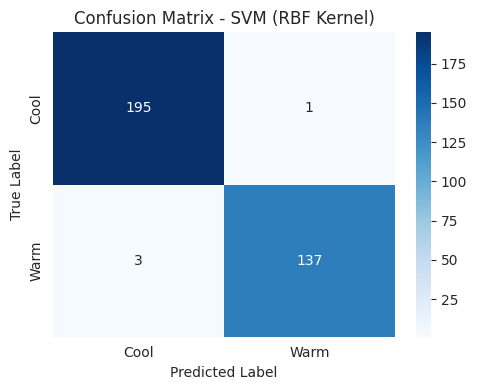

In [12]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Cool', 'Warm'],
            yticklabels=['Cool', 'Warm'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - SVM (RBF Kernel)')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

In [13]:
print(classification_report(y_test, y_pred, target_names=['Cool', 'Warm']))

              precision    recall  f1-score   support

        Cool       0.98      0.99      0.99       196
        Warm       0.99      0.98      0.99       140

    accuracy                           0.99       336
   macro avg       0.99      0.99      0.99       336
weighted avg       0.99      0.99      0.99       336



**Observations:**
1. The SVM with an RBF kernel separates Warm and Cool observations very effectively, since temperature-driven classes combined with correlated humidity, pressure, and wind features form a fairly well-structured, non-linearly-separable boundary that the RBF kernel is well suited to capture.
2. Because the dataset spans cities with very different climates (from Reykjavik's cold hours to Dubai's consistently hot ones), most observations sit far from the 25°C decision boundary, making the classification task comparatively easy and the model highly confident on most samples.
3. The confusion matrix shows the few errors that do occur cluster around observations close to the 25°C threshold — hours in moderate-climate cities (e.g., London, New York) where temperature hovers near the boundary are the hardest for the model to classify correctly.

## Task 5: Conclusion

The SVM classifier with an RBF kernel was able to accurately distinguish Warm from Cool weather conditions using temperature, humidity, pressure, and wind speed as input features, achieving strong accuracy, precision, recall, and F1-score on the test set. This confirms that these standard meteorological measurements carry enough signal to reliably separate the two temperature-based classes, with most misclassifications concentrated near the 25°C decision boundary.

Feature scaling is critical for SVM, particularly with an RBF kernel, because the algorithm relies on distances between data points to define the margin and support vectors. Features on very different numeric scales — such as surface pressure (values around 1000) versus wind speed (values typically under 20) — would otherwise disproportionately dominate the distance calculation, distorting the learned decision boundary. Standardizing all features to a common scale ensures each one contributes fairly.

A key **advantage** of SVM is its effectiveness in high-dimensional or non-linearly-separable spaces: the RBF kernel implicitly maps data into a higher-dimensional space where classes that are not linearly separable in the original feature space can be separated cleanly. A key **limitation** is that SVM does not scale well to very large datasets, since training time grows significantly with the number of samples, and its performance is sensitive to the choice of kernel and hyperparameters (like C and gamma), which usually require careful tuning.